# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import astropy.io
from scipy.integrate import quad
from scipy.special import gamma
from scipy.optimize import minimize
from scipy.stats import norm

In [14]:
data

array([29.294196, 29.039727, 23.094946, 22.420457, 22.517914, 30.768244,
       38.438099, 19.480969, 46.725634, 26.029244, 27.252466, 20.770669,
       24.383101, 23.399619, 28.368295, 24.192691, 26.708939, 26.335891,
       20.028165, 29.873379, 27.480813, 23.765412, 26.465773, 24.341906,
       24.960074, 25.896629, 22.468376, 25.668677, 25.067537, 19.241216,
       24.648017, 26.318043, 60.196693, 58.184542, 35.76529 , 24.742844,
       47.781858, 26.730807, 23.222786, 42.873973, 25.265269, 28.554701,
       23.564841, 26.211784, 56.075838,  1.019527, 63.31045 , 26.889764,
        4.016237,  1.245036, 27.389175, 26.429964, 57.462091, 28.078846,
       25.74546 , 25.602824, 39.641015, 21.437224, 28.133254, 26.657423,
       24.04768 , 26.577977, 30.93364 , 35.629988, 24.279683, 27.517997,
       21.78576 , 26.310955, 27.570539, 14.95205 , 11.877623, 23.72816 ,
       10.025923,  6.746372, 24.25694 , 24.012146, 28.831749, 25.288248,
       25.551463, 24.007645, 27.836083, 26.432498, 

The naive estimator finds that the sample mean of the photon counts (i.e. the estimate of the star's position) is 26.460
It also finds that the uncertainty on the position is roughly 0.364


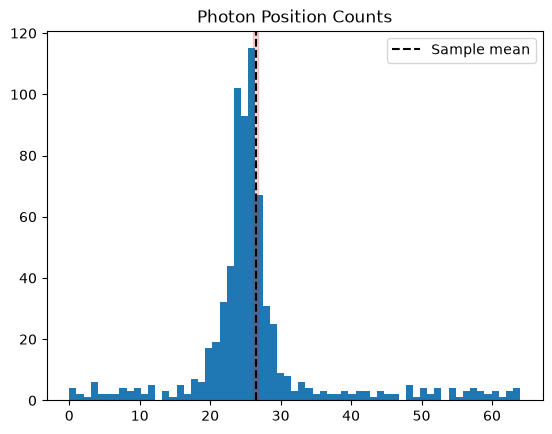

In [2]:
# Part 1: your work here
data = np.array(astropy.io.ascii.read('../../labs/02/data/jonaham2.csv')['x'])

sample_mean = np.mean(data)
uncertainty = np.std(data)/np.sqrt(len(data))

print(f'The naive estimator finds that the sample mean of the photon counts (i.e. the estimate of the star\'s position) is {sample_mean:.3f}')
print(f'It also finds that the uncertainty on the position is roughly {uncertainty:.3f}')

bins = np.linspace(0, 64, 64)

plt.hist(data, bins=bins)
plt.axvline(sample_mean, c='black', ls='--', label='Sample mean')
plt.axvspan(sample_mean - uncertainty, sample_mean + uncertainty, color='C3', alpha=0.2)
plt.title('Photon Position Counts')
plt.legend()
plt.show()

**ANSWER (a few sentences):**

The initial analysis done with a naive estimator finds that the sample mean of $\hat{x}_0 = 26.460$ with an uncertainty $\sigma = 0.364$, for an estimated stellar position of $26.460 \pm 0.364$. This estimator is clearly biased, as can be clearly seen in the extended right-hand tail of the histogram. The bias arises from the arithmetic conducted on the data to calculate the mean (e.g. summing of photon positions and division by the number of photons, N). The size of this bias is dependent on the number of photons that the detector is able to collect, as the higher the number of photons means there will be more manipulation of the data present.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

## Median Histogram

The naive estimator finds that the sample median of the photon counts (i.e. the estimate of the star's position) is 25.245
It also finds that the uncertainty on the position is roughly 0.364


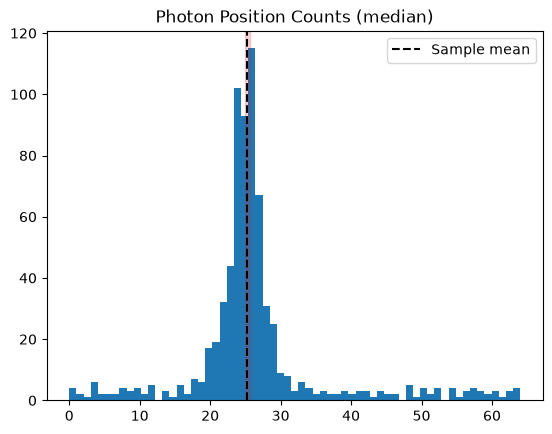

In [3]:
# Part 2: your work here

sample_median = np.median(data)
uncert2 = np.std(data)/np.sqrt(len(data))

print(f'The naive estimator finds that the sample median of the photon counts (i.e. the estimate of the star\'s position) is {sample_median:.3f}')
print(f'It also finds that the uncertainty on the position is roughly {uncert2:.3f}')

plt.hist(data, bins=bins)
plt.axvline(sample_median, c='black', ls='--', label='Sample mean')
plt.axvspan(sample_median - uncert2, sample_median + uncert2, color='C3', alpha=0.2)
plt.title('Photon Position Counts (median)')
plt.legend()
plt.show()

This method, using the median to measure the centroid of the distribution, is much less biased than using the mean, as there is no arithmetic being conducted on the data recorded. This means that the data isn't being manipulated, and the bias is independent from the number of measurements taken.

## K$\sigma$-Clipping

In [4]:
def sigma_clip_fit(data, k=3.0, max_iter=10):
    mask = np.ones_like(data, dtype=bool)
    for _ in range(max_iter):
        mean = np.mean(data[mask])
        sig = np.std(data[mask])
        new_mask = np.abs(data-mean) < k*sig
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return data[mask], sig, mask

The mean of the sigma-clipped data is 24.938
The uncertainty of the mean estimate is 2.542
The fraction of data was clipped through sigma-clipping is 0.184


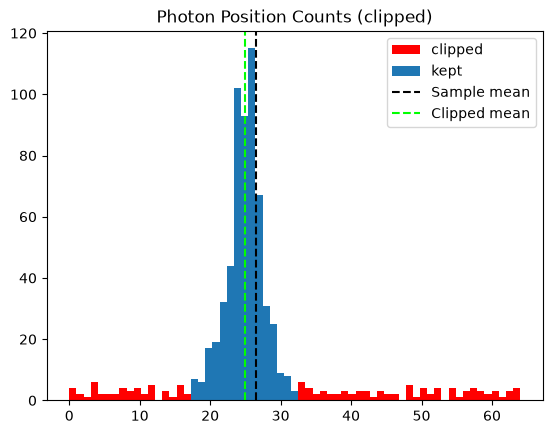

In [5]:
clipped_data, uncert3, __ = sigma_clip_fit(data)
sc_fb = (1-(len(clipped_data)/len(data)))

print(f'The mean of the sigma-clipped data is {np.mean(clipped_data):.3f}')
print(f'The uncertainty of the mean estimate is {uncert3:.3f}')
print(f'The fraction of data was clipped through sigma-clipping is {sc_fb:.3f}')

plt.hist(data, bins=bins, color='red', label='clipped')
plt.hist(clipped_data, bins=bins, label='kept')
plt.axvline(np.mean(data), c='black', ls='--', label='Sample mean')
plt.axvline(np.mean(clipped_data), c='lime', ls='--', label='Clipped mean')
plt.title('Photon Position Counts (clipped)')
plt.legend()
plt.show()

Through the $\sigma$-clipping method, we can see that it cut out a lot of the background noise apparent in the histogram, shortening the tails. I chose a clipping value of $3\sigma$ because it encompasses roughly 98 percent of the data, meaning most of the noise would be cut yet leave the majority of the data untouched. I also experimented with a threshold of $2\sigma$, and found that it was way too restrictive, clipping many of the points that were clearly part of the star's distribution.

## Maximum Likelihood on the Mixture Model

Maximum likelihood mean: x0 = 25.06 +- 0.105
Background fraction = 0.22 +- 0.019


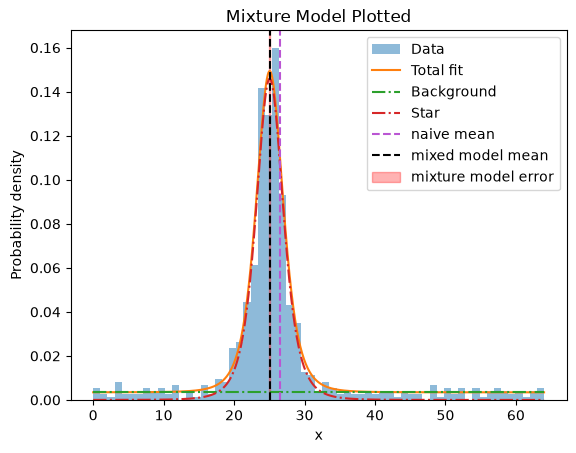

In [6]:
# USED AI

def neg_log_likelihood(theta, x):
    b = 2.5
    r0 = 4
    x0,fbg = theta
    model = (fbg/64) + ((1-fbg)*gamma(b)/(r0*np.sqrt(np.pi)*gamma(b-.5)))*(1+((x-x0)/r0)**2)**-b
    return -np.sum(np.log(model))

sc_x0 = np.mean(clipped_data)

theta0 = [sc_x0, sc_fb]
result = minimize(neg_log_likelihood, theta0, args=(data), method='Nelder-Mead')
mm_x0,mm_fbg = result.x

def hessian(func, theta, x, eps=1e-5):
    n = len(theta)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            di = np.zeros(n)
            dj = np.zeros(n)
            di[i] = eps
            dj[j] = eps

            H[i,j] = (func(theta + di + dj, x) - func(theta + di - dj, x) - func(theta - di + dj, x) + func(theta - di - dj, x))/(4*eps**2)
    return H

H = hessian(neg_log_likelihood, result.x, data)

cov = np.linalg.inv(H)

mm_x0_sig  = np.sqrt(cov[0,0])
mm_fbg_sig = np.sqrt(cov[1,1])

xx = np.linspace(0, 64, 1000)

b = 2.5
r0 = 4

moffat = (gamma(b)/(r0*np.sqrt(np.pi)*gamma(b-0.5)) * (1 + ((xx-mm_x0)/r0)**2)**(-b))

bg = np.ones_like(xx)/64

model = mm_fbg*bg + (1-mm_fbg)*moffat

plt.hist(data, bins=bins, density=True,
         alpha=0.5, label='Data')

plt.plot(xx, model, label='Total fit')
plt.plot(xx, mm_fbg*bg, '-.', label='Background')
plt.plot(xx, (1-mm_fbg)*moffat, '-.', label='Star')

plt.axvline(sample_mean, c = 'mediumorchid', label = 'naive mean', ls = '--')
plt.axvline(mm_x0, c = 'k', label = 'mixed model mean', ls = '--')
plt.axvspan((mm_x0-mm_x0_sig), mm_x0+mm_x0_sig, color='red', alpha=0.3, label='mixture model error')

plt.title('Mixture Model Plotted')
plt.xlabel('x')
plt.ylabel('Probability density')
plt.legend()

print(f"Maximum likelihood mean: x0 = {mm_x0:.2f} +- {mm_x0_sig:.3f}\nBackground fraction = {mm_fbg:.2f} +- {mm_fbg_sig:.3f}")

In [7]:
# defining functions for computing the cramer-rao bound -- USED AI

def p(x,x0,fbg):
    t_moffat = (gamma(b)/(r0*np.sqrt(np.pi)*gamma(b-0.5)) * (1 + ((x-x0)/r0)**2)**(-b))
    return fbg/64 + (1-fbg)*t_moffat
def dp_dx0(x,x0,fbg):
    A = (gamma(b)/(r0*np.sqrt(np.pi)*gamma(b-0.5)))
    u = 1 + ((x-x0)/r0)**2
    return ((1-fbg)*2*A*b*(x-x0)/r0**2)*u**(-b-1)


def I_x0(x0, fbg):
    integrand = lambda x: (
        dp_dx0(x, x0, fbg)**2
        / p(x, x0, fbg)
    )
    I, err = quad(integrand, 0, 64)
    return I

In [8]:
I = I_x0(mm_x0,mm_fbg)
n = len(data)
sig_cr = 1/np.sqrt(n*I)

print(f'Cramer-Rao: {sig_cr:.3f}')

Cramer-Rao: 0.106


**FINAL ANSWER:** $x_0 = $ 25.06 $\pm$ 0.105 px , $f_{\rm bg} = $ 0.22 $\pm$ 0.019 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.106 px

**Justification and uncertainty method (a short paragraph):**

I chose to go with the Maximum Likelihood Mixture Model for analysis of this datset, as it provided a mean and uncertainties most closely aligned with a set of unbiased data. The uncertainties for the parameters were calculated from the Hessian matrix, with the curvature of the function being approximated at its peak. The uncertainties in this model are very acceptable, given our 3x the cramer-rao bound limit, as the uncertainty for the distribution mean is exactly the same as the cramer-rao bound: the uncertainty of an unbiased estimator. This means that the uncertainty of the Maximum Likelihood Mixture Model is the best estimate of the uncertainty out of all of the estimators used so far.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

For my verification plan, I will simulate a dataset with a mean and uncertainty known to me

In [9]:
# Part 3b: execute the plan here

**WHAT THE CHECKS FOUND:**

*your report goes here*

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

In part 2, I used Copilot to generate code for the maximum likelihood function